## Question: "Which disperser/filter detects my line fastest?"

### Some NIRSpec Docs
- [Dispersers & Filters](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-instrumentation/nirspec-dispersers-and-filters#gsc.tab=0)
- [Recommended Strategies](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-observing-strategies/nirspec-detector-recommended-strategies#gsc.tab=0)


In [1]:
# Pandeia reference data
import os
os.environ["pandeia_refdata"] = "../data/pandeia_data-2026.2-jwst"
os.environ["PSF_DIR"] = "../data/pandeia_psfs-2026.2-jwst"
os.environ["PYSYN_CDBS"] = "../data/grp/redcat/trds"

from pandeia.engine.calc_utils import build_default_calc
from pandeia.engine.perform_calculation import perform_calculation
import matplotlib.pyplot as plt
import numpy as np

telescope = 'jwst'
instrument = 'nirspec'
mode = 'fixed_slit'
readout_pattern = 'nrsirs2'

# Fixed-slit aperture (the coverage/detector gap depends on this)
aperture = 's200a1'

# Fixed exposure (identical across dispersers -> fair comparison at equal time)
ngroups, nint, nexp = 190, 6, 3

# Disperser / filter combinations to compare
dispersers = [('prism', 'clear'), ('g235m', 'f170lp'),
              ('g395m', 'f290lp'), ('g395h', 'f290lp')]

# Emission line
name = 'H alpha'
line_rest_um = 0.6563
line_width_kms = 1000        # velocity FWHM
line_strength = 2e-18        # erg/s/cm2
redshift = 5

# Reference S/N for the "time to detect" comparison
target_snr = 10.0

c_kms = 299792.458
obs_wavelength = line_rest_um * (1 + redshift)   # observed-frame line center (um)

In [2]:
# NIRSpec fixed-slit coverage and detector gaps, read from Pandeia's slit_config.
import json
_gap = json.load(open(f"{os.environ['pandeia_refdata']}/jwst/nirspec/config.json"))['slit_config'][aperture]['gap']['default']


def covers_line(disp, filt):
    """True if the observed line is inside this disperser's coverage and not in the gap."""
    node = _gap[disp]
    v = node if 'wave_min' in node else node[filt]   # some gratings nest by filter
    wmin, wmax = v['wave_min'], v['wave_max']
    if not (wmin <= obs_wavelength <= wmax):
        return False, (wmin, wmax)
    gs, ge = v['gap_start'], v['gap_end']
    if gs is not None and gs <= obs_wavelength <= ge:
        return False, (wmin, wmax)
    return True, (wmin, wmax)


def build_calc(disp, filt):
    calc = build_default_calc(telescope, instrument, mode)
    calc['configuration']['instrument']['disperser'] = disp
    calc['configuration']['instrument']['filter'] = filt
    det = calc['configuration']['detector']
    det['readout_pattern'] = readout_pattern
    det['ngroup'] = ngroups
    det['nint'] = nint
    det['nexp'] = nexp
    calc['background_level'] = 'low'
    scene = calc['scene'][0]
    scene['shape']['geometry'] = 'point'
    scene['spectrum']['sed'] = {'sed_type': 'no_continuum'}   # pure emission line
    scene['spectrum']['redshift'] = 0
    scene['spectrum']['lines'] = [{
        'id': 0, 'name': name, 'emission_or_absorption': 'emission',
        'center': obs_wavelength, 'width': line_width_kms,
        'strength': line_strength, 'profile': 'gaussian'}]
    return calc


def line_snr_fixed_exposure(disp, filt):
    """Integrated line S/N at the fixed exposure, using a resolution-matched window."""
    rep = perform_calculation(build_calc(disp, filt))
    w = np.asarray(rep['1d']['extracted_flux'][0])
    f = np.asarray(rep['1d']['extracted_flux'][1])
    n = np.asarray(rep['1d']['extracted_noise'][1])

    # local dispersion -> instrumental line-spread function (~2 pixels FWHM)
    i = int(np.argmin(np.abs(w - obs_wavelength)))
    dwave = np.median(np.diff(w)[max(0, i - 5):i + 5])
    fwhm_lsf = 2.0 * dwave
    fwhm_intrinsic = obs_wavelength * line_width_kms / c_kms
    fwhm_obs = np.hypot(fwhm_lsf, fwhm_intrinsic)   # observed line = intrinsic conv LSF
    sigma_obs = fwhm_obs / 2.3548

    dist = np.abs(w - obs_wavelength)
    line = dist <= 3 * sigma_obs
    side = (dist > 3 * sigma_obs) & (dist <= 7 * sigma_obs)
    continuum = np.median(f[side]) if side.any() else 0.0
    snr = np.sum(f[line] - continuum) / np.sqrt(np.sum(n[line] ** 2))

    return dict(snr=snr, R=obs_wavelength / fwhm_lsf, npix=int(line.sum()),
                total_time=rep['information']['exposure_specification']['total_exposure_time'],
                rep=rep)

Line: H alpha at z=5  ->  observed 3.9378 um

prism /clear : R~  192, S/N= 38.09 in 26670s (6 pix)  ->  reaches S/N=10.0 in 0.51 h
g235m /f170lp: line NOT covered (1.66-3.07 um) -- skipped
g395m /f290lp: R~ 1097, S/N= 31.51 in 26670s (20 pix)  ->  reaches S/N=10.0 in 0.75 h
g395h /f290lp: R~ 2962, S/N= 23.91 in 26670s (51 pix)  ->  reaches S/N=10.0 in 1.30 h

=== Fastest to detect H alpha at S/N=10.0: prism/clear (0.51 h) ===
  prism /clear : 0.51 h  (1.00x)
  g395m /f290lp: 0.75 h  (1.46x)
  g395h /f290lp: 1.30 h  (2.54x)


/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/report.py:746: RuntimeWarning: divide by zero encountered in divide
  sn = self.extracted['extracted_flux'] / self.extracted['extracted_noise']
/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/projection.py:78: RuntimeWarning: invalid value encountered in divide
  self.detector_sn = (s - self.bg_pix) / n


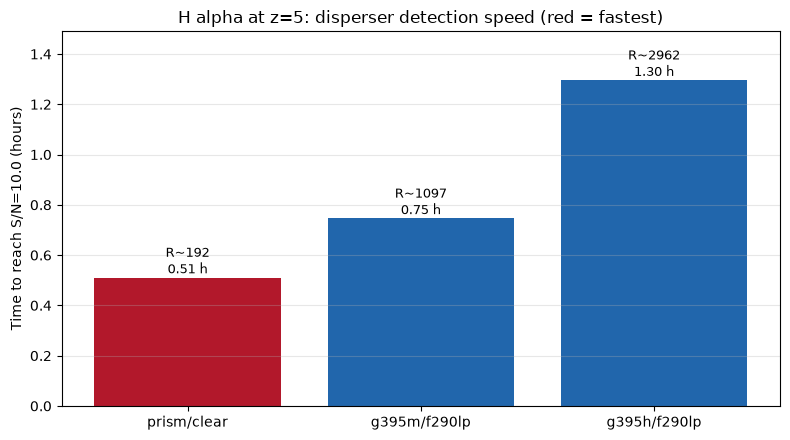

In [3]:
print(f"Line: {name} at z={redshift}  ->  observed {obs_wavelength:.4f} um\n")

results = []
for disp, filt in dispersers:
    covered, (wmin, wmax) = covers_line(disp, filt)
    if not covered:
        print(f"{disp:6}/{filt:6}: line NOT covered ({wmin:.2f}-{wmax:.2f} um) -- skipped")
        continue
    r = line_snr_fixed_exposure(disp, filt)
    # time to reach target_snr (S/N grows as sqrt(time))
    t_detect = r['total_time'] * (target_snr / r['snr']) ** 2
    r.update(disp=disp, filt=filt, t_detect=t_detect)
    results.append(r)
    print(f"{disp:6}/{filt:6}: R~{r['R']:5.0f}, S/N={r['snr']:6.2f} in {r['total_time']:.0f}s "
          f"({r['npix']} pix)  ->  reaches S/N={target_snr} in {t_detect/3600:.2f} h")

results.sort(key=lambda x: x['t_detect'])
fastest = results[0]
print(f"\n=== Fastest to detect {name} at S/N={target_snr}: "
      f"{fastest['disp']}/{fastest['filt']} ({fastest['t_detect']/3600:.2f} h) ===")
for r in results:
    factor = r['t_detect'] / fastest['t_detect']
    print(f"  {r['disp']:6}/{r['filt']:6}: {r['t_detect']/3600:.2f} h  ({factor:.2f}x)")

# Bar chart: time to detect, annotated with resolving power
labels = [f"{r['disp']}/{r['filt']}" for r in results]
times_h = np.array([r['t_detect'] / 3600 for r in results])
colors = ['#b2182b' if r is fastest else '#2166ac' for r in results]
plt.figure(figsize=(8, 4.5))
bars = plt.bar(labels, times_h, color=colors)
for r, b in zip(results, bars):
    plt.text(b.get_x() + b.get_width() / 2, b.get_height(),
             f"R~{r['R']:.0f}\n{times_h[results.index(r)]:.2f} h",
             ha='center', va='bottom', fontsize=9)
plt.ylabel(f'Time to reach S/N={target_snr} (hours)')
plt.title(f'{name} at z={redshift}: disperser detection speed (red = fastest)')
plt.margins(y=0.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()